# 📊 01. Exploratory Data Analysis (EDA)


In [1]:
payment_sum = payments.groupby('order_id')['payment_value'].sum().reset_index()
item_count = order_items.groupby('order_id').size().reset_index(name='item_count')
df = orders.merge(payment_sum, on='order_id', how='left')
df = df.merge(item_count, on='order_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
orders['is_return'] = orders['order_status'].apply(lambda x: 1 if x == 'canceled' else 0)
orders['Trả hàng'] = orders['is_return'].map({0: 'Không', 1: 'Có'})
df = df.merge(orders[['order_id', 'is_return', 'Trả hàng']], on='order_id', how='left')


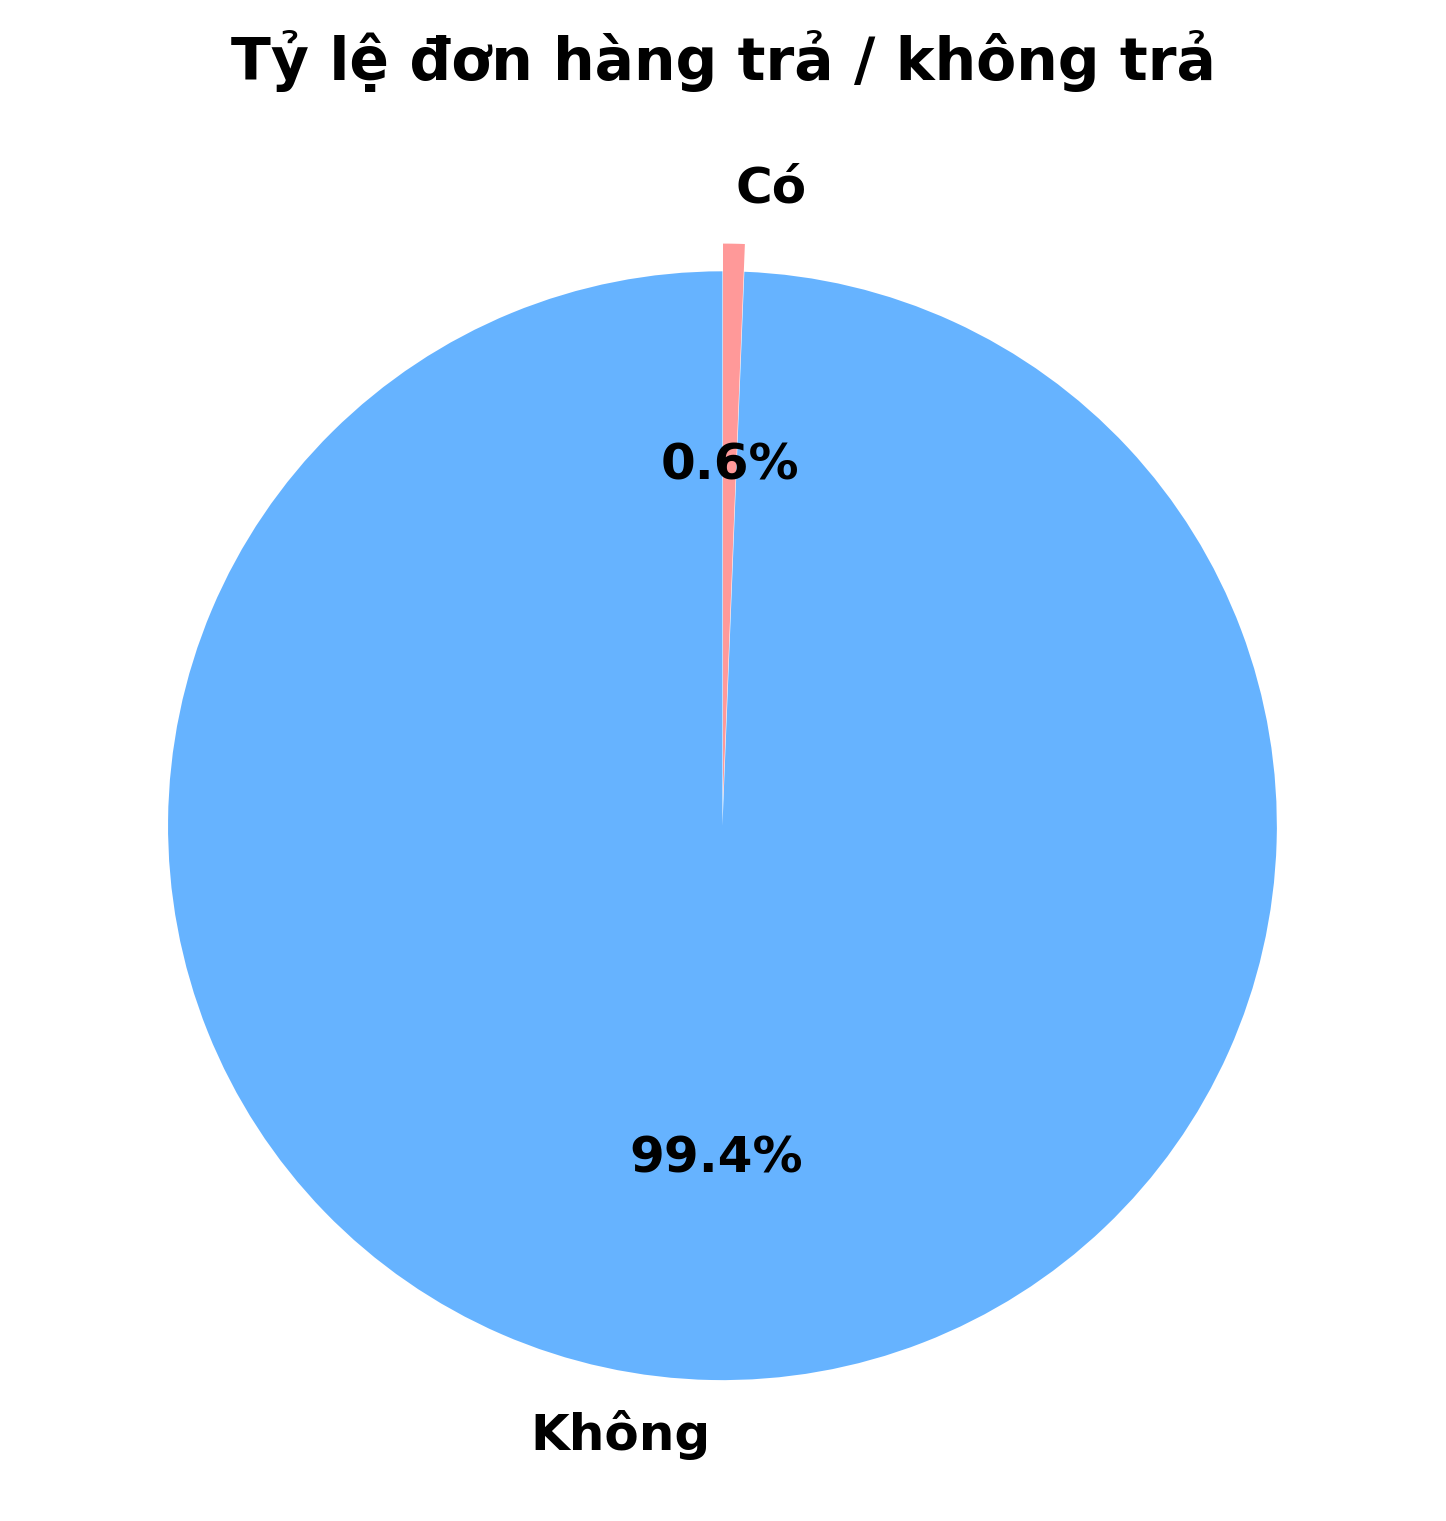

In [1]:
plt.pie(orders['Trả hàng'].value_counts(), autopct='%1.1f%%', startangle=90)